In [ ]:
from IPython.display import display, HTML
display(HTML("""
<h1>Predictive Analytics Project</h1>

<h3><b>Problem Statement</b></h3>
<p>
Hospital readmissions are a significant challenge in healthcare, leading to increased costs and poorer patient outcomes. Identifying patients at risk of readmission can help improve care and reduce unnecessary hospital utilization.
</p>

<h3><b>Project Objective</b></h3>
<p>
The objective of this project is to build a classification model that predicts whether a patient will be readmitted within 30 days.
</p>
"""))

In [50]:
from IPython.display import display, HTML
display(HTML("""
<h3><b>Data Source</b></h3>
<p>
The dataset used for this analysis was obtained from Kaggle and contains patient-level hospital data, including demographic information, diagnoses, and hospital utilization metrics.
</p>
"""))

In [63]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif;margin-bottom: 20px;">
    <h3><b>Data Description</b></h3>
    <p>
    The dataset contains over 100,000 patient records and more than 50 variables. These include demographic, clinical, and utilization-related features such as age, number of medications, and prior hospital visits. The target variable, “readmitted,” indicates whether a patient was readmitted within 30 days, after 30 days, or not readmitted.
    </p>
</div>
"""))

In [65]:
import pandas as pd

df = pd.read_csv('diabetic_data.csv')
df.columns = df.columns.str.strip()

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [66]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [ ]:
df['readmitted'].value_counts()
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

df['readmitted_binary'].value_counts()

,count
readmitted_binary,
0,90409
1,11357


In [ ]:
(df == '?').sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


In [ ]:
df.groupby('readmitted_binary')['time_in_hospital'].mean()
df.groupby('readmitted_binary')['num_medications'].mean()
df.groupby('readmitted_binary')['number_inpatient'].mean()

,number_inpatient
readmitted_binary,
0,0.561648
1,1.224003


In [ ]:
from IPython.display import display, HTML

display(HTML("""
<h3><b>Exploratory Data Analysis</b></h3>
<p>
Exploratory data analysis revealed several important trends. Patients who were readmitted tended to have a higher number of prior inpatient visits and slightly longer hospital stays. Additionally, the target variable was imbalanced, with more patients not readmitted than readmitted within 30 days. These patterns suggest that prior healthcare utilization is a strong predictor of readmission risk.
</p>
"""))

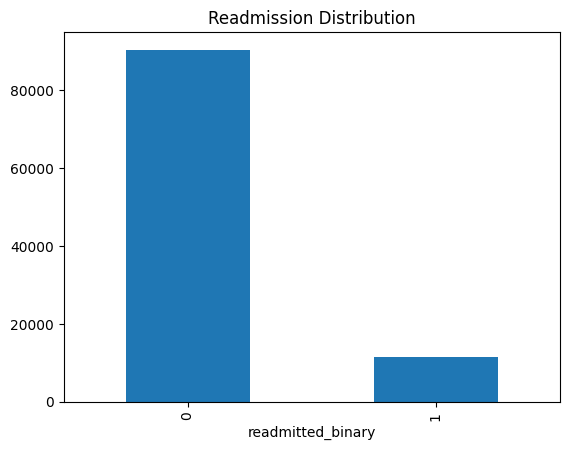

In [ ]:
import matplotlib.pyplot as plt

df['readmitted_binary'].value_counts().plot(kind='bar')
plt.title('Readmission Distribution')
plt.show()

In [68]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; margin-bottom: 20px;">
    <p>
    The distribution of the target variable shows that significantly more patients were not readmitted within 30 days compared to those who were. This class imbalance may affect model performance and helps explain why the model initially struggled to correctly identify readmitted patients.
    </p>
</div>
"""))

In [59]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif;">
    <h2>Analysis</h2>
</div>
"""))

In [70]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; margin-bottom: 20px;">
    <h3><b>Data Preparation</b></h3>
    <p>
    Before modeling, the dataset was cleaned and prepared to ensure accuracy and consistency. Missing values represented as “?” were converted to null values and handled appropriately. Variables with excessive missing data, including weight, payer code, and medical specialty, were removed. Identifier columns such as encounter ID and patient number were also excluded, as they do not contribute to prediction. Categorical variables were converted into numerical format using one-hot encoding. The dataset was then split into training and testing sets using an 80/20 split.
    </p>
</div>
"""))

In [78]:
df = df.replace('?', pd.NA)

df = df.drop(columns=['encounter_id', 'patient_nbr'], errors='ignore')
df = df.drop(columns=['weight', 'payer_code', 'medical_specialty'], errors='ignore')
df = df.drop(columns=['readmitted'], errors='ignore')

df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_binary
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [ ]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)

(101766, 2331)


In [ ]:
X = df.drop('readmitted_binary', axis=1)
y = df['readmitted_binary']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(81412, 2330) (20354, 2330)


In [72]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif; margin-bottom: 20px;">
    <h3><b>Modeling Techniques</b></h3>
    <p>
    Two models were evaluated for this analysis: Logistic Regression and Random Forest. Logistic Regression was used as a baseline model due to its simplicity and interpretability, while Random Forest was selected for its ability to capture more complex relationships in the data.
    </p>
</div>
"""))

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=300, solver='liblinear')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8870492286528446
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18069
           1       0.42      0.02      0.03      2285

    accuracy                           0.89     20354
   macro avg       0.66      0.51      0.49     20354
weighted avg       0.84      0.89      0.84     20354



In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6458681340277096
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18069
           1       0.17      0.56      0.26      2285

    accuracy                           0.65     20354
   macro avg       0.55      0.61      0.51     20354
weighted avg       0.84      0.65      0.71     20354



In [57]:
from IPython.display import display, HTML

display(HTML("""
<div style="font-family: Arial, sans-serif;">
    <h3><b>Model Evaluation</b></h3>
    <p>
    The Random Forest model achieved a high overall accuracy; however, initial results showed that the model struggled to correctly identify readmitted patients due to class imbalance. After applying class weighting, the model improved its ability to detect readmissions, although performance for the minority class remains lower compared to the majority class.
    </p>
</div>
"""))

In [75]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
9,number_inpatient,0.208522
1,discharge_disposition_id,0.083391
6,num_medications,0.045519
3,time_in_hospital,0.040605
8,number_emergency,0.040537
10,number_diagnoses,0.021517
4,num_lab_procedures,0.020336
734,diag_1_V58,0.016938
818,diag_2_250,0.014031
979,diag_2_401,0.013256


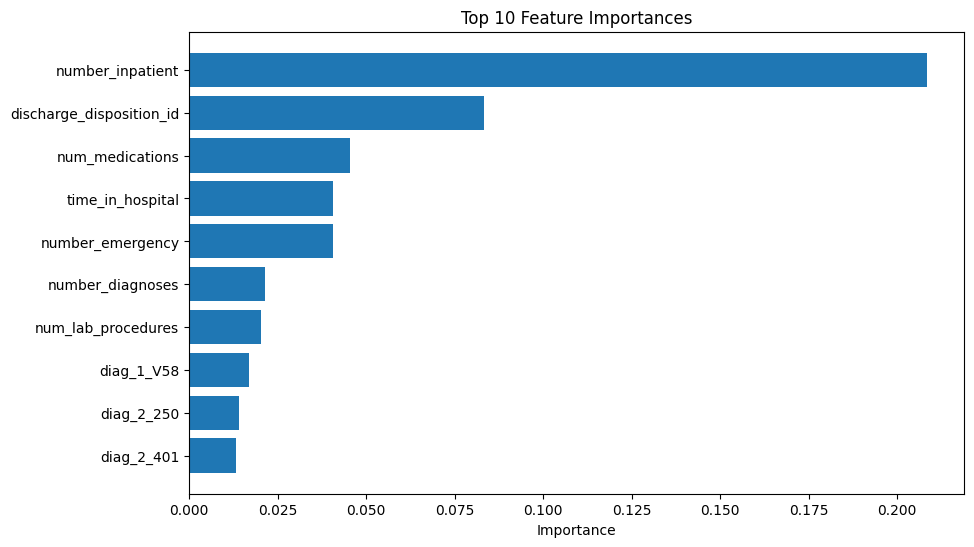

In [45]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.show()

In [46]:
from IPython.display import display, HTML

display(HTML("""
<h3><b>Key Predictors Explanation</b></h3>
<p>
The analysis identified several important predictors of hospital readmission, including prior inpatient visits, number of medications, and time spent in the hospital. These variables suggest that patients with higher healthcare utilization and more complex medical needs are at greater risk of readmission.
</p>
"""))

In [49]:
from IPython.display import display, HTML

display(HTML("""
<h2>Conclusion</h2>

<h3><b>Summary of Results</b></h3>
<p>
This analysis developed a predictive model to identify patients at risk of hospital readmission within 30 days. Among the models tested, Random Forest performed best and was selected as the final model.
</p>

<h3><b>Recommendations and Limitations</b></h3>
<p>
Hospitals can use this model to identify high-risk patients and implement targeted interventions to reduce readmissions. However, the model is limited by class imbalance and missing data, which may impact predictive performance.
</p>
"""))